In [ ]:
# ===============================
# 📦 Install Dependencies
# ===============================
!pip install transformers accelerate torch torchvision scikit-learn matplotlib seaborn --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 45.1 MB/s eta 0:00:00


In [ ]:
# ===============================
# 🔄 Setup & Load CLIP Model
# ===============================
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import os
from google.colab import drive

In [ ]:
# ===============================
# 🔄 Setup & Load CLIP Model
# ===============================
from transformers import CLIPProcessor, CLIPModel
from PIL import Image
import torch
import os
from google.colab import drive

In [ ]:
# Mount Drive
drive.mount('/content/drive')

# Paths
base_path = '/content/drive/MyDrive/TRB2026_sharmin/css-data'
subfolders = ['test', 'valid']
result_folder_name = "result_clip_fewshot"

Mounted at /content/drive


In [ ]:
# Load CLIP
model_version = "openai/clip-vit-base-patch16"
clip_model = CLIPModel.from_pretrained(model_version)
clip_processor = CLIPProcessor.from_pretrained(model_version)
clip_model.to("cuda" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/599M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [ ]:
# ===============================
# 🧠 Label Names
# ===============================
label_names = {
    0: "Helmet",
    7: "Safety Vest",
    6: "Safety Cone",
    8: "Machinery",
    9: "Vehicle"
}

# ===============================
# 🧠 Prompt Templates per Label
# ===============================
prompt_templates = {
    0: [
        "A construction worker wearing a helmet",
        "A man with a hard hat on a construction site",
        "A person following helmet safety guidelines",
        "Someone protected by headgear"
    ],
    7: [
        "A worker in a safety vest",
        "A person wearing a high-visibility vest",
        "Someone complying with vest regulations",
        "A laborer with safety clothing"
    ],
    6: [
        "A traffic cone",
        "An orange safety cone",
        "A road cone near a work area",
        "A construction zone cone"
    ],
    8: [
        "Construction machinery",
        "Heavy equipment on site",
        "A bulldozer or excavator",
        "Machinery used in construction"
    ],
    9: [
        "A construction vehicle",
        "A dump truck or mixer on site",
        "A heavy truck for construction",
        "A vehicle in a work zone"
    ]
}

In [ ]:
# ===============================
# 🧠 Few-Shot Prompt Classification Function
# ===============================
def classify_clip_fewshot(image_path, prompt_templates, threshold=0.3):
    image = Image.open(image_path).convert("RGB")
    predicted_labels = []

    for label_id, templates in prompt_templates.items():
        scores = []
        for template in templates:
            inputs = clip_processor(text=[template], images=image, return_tensors="pt", padding=True).to(clip_model.device)
            with torch.no_grad():
                outputs = clip_model(**inputs)
                prob = outputs.logits_per_image.softmax(dim=1)[0][0].item()
                scores.append(prob)

        avg_score = sum(scores) / len(scores)
        if avg_score > threshold:
            predicted_labels.append(label_id)

    return predicted_labels

In [ ]:
# ===============================
# 🚀 Inference Loop
# ===============================
for sub in subfolders:
    image_folder = os.path.join(base_path, sub, "images")
    output_label_folder = os.path.join(base_path, sub, result_folder_name)
    os.makedirs(output_label_folder, exist_ok=True)

    for img_file in os.listdir(image_folder):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(image_folder, img_file)
        predicted_labels = classify_clip_fewshot(img_path, prompt_templates)

        label_filename = os.path.splitext(img_file)[0] + ".txt"
        output_path = os.path.join(output_label_folder, label_filename)
        with open(output_path, 'w') as f:
            for label in sorted(predicted_labels):
                f.write(f"{label}\n")

print("✅ CLIP few-shot predictions saved to:", result_folder_name)

✅ CLIP few-shot predictions saved to: result_clip_fewshot


In [ ]:
# ===============================
# 📊 Evaluation
# ===============================
true_labels, pred_labels = [], []
for sub in subfolders:
    image_dir = os.path.join(base_path, sub, "images")
    gt_dir = os.path.join(base_path, sub, "labels_superclean(GT)")
    pred_dir = os.path.join(base_path, sub, result_folder_name)

    for file in os.listdir(image_dir):
        if not file.endswith(('.jpg', '.jpeg', '.png')):
            continue
        name = os.path.splitext(file)[0]
        gt_path = os.path.join(gt_dir, name + ".txt")
        pr_path = os.path.join(pred_dir, name + ".txt")
        if not os.path.exists(gt_path) or not os.path.exists(pr_path):
            continue
        with open(gt_path) as f:
            gt = [int(x.strip()) for x in f if x.strip().isdigit()]
        with open(pr_path) as f:
            pr = [int(x.strip()) for x in f if x.strip().isdigit()]
        true_labels.append(gt)
        pred_labels.append(pr)

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

mlb = MultiLabelBinarizer(classes=sorted(prompt_templates.keys()))
y_true = mlb.fit_transform(true_labels)
y_pred = mlb.transform(pred_labels)

# Metrics
micro_precision = precision_score(y_true, y_pred, average='micro', zero_division=0)
micro_recall = recall_score(y_true, y_pred, average='micro', zero_division=0)
micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)
macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

# Classification report
report = classification_report(
    y_true, y_pred,
    target_names=[label_names[l] for l in mlb.classes_],
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report).T.round(3)

# Define export directory and create it if it doesn't exist
export_dir = os.path.join(base_path, "evaluation_results")
os.makedirs(export_dir, exist_ok=True)

report_df_path = os.path.join(export_dir, "classification_report.csv")
report_df.to_csv(report_df_path)

# Print evaluation summary
print("\n✅ Evaluation Summary")
print("="*50)
print(report_df)
print(f"\nMicro F1: {micro_f1:.3f}, Precision: {micro_precision:.3f}, Recall: {micro_recall:.3f}")
print(f"Macro F1: {macro_f1:.3f}, Precision: {macro_precision:.3f}, Recall: {macro_recall:.3f}")

# Save summary CSV
summary_df = pd.DataFrame({
    'Metric': ['Micro Precision', 'Micro Recall', 'Micro F1', 'Macro Precision', 'Macro Recall', 'Macro F1'],
    'Score': [micro_precision, micro_recall, micro_f1, macro_precision, macro_recall, macro_f1]
}).round(3)
summary_df.to_csv(os.path.join(export_dir, "summary_metrics.csv"), index=False)
print(summary_df)


✅ Evaluation Summary
              precision  recall  f1-score  support
Helmet            0.367   1.000     0.537     72.0
Safety Cone       0.107   1.000     0.194     21.0
Safety Vest       0.255   1.000     0.407     50.0
Machinery         0.245   1.000     0.393     48.0
Vehicle           0.158   1.000     0.273     31.0
micro avg         0.227   1.000     0.369    222.0
macro avg         0.227   1.000     0.361    222.0
weighted avg      0.262   1.000     0.407    222.0
samples avg       0.227   0.689     0.327    222.0

Micro F1: 0.369, Precision: 0.227, Recall: 1.000
Macro F1: 0.361, Precision: 0.227, Recall: 1.000
            Metric  Score
0  Micro Precision  0.227
1     Micro Recall  1.000
2         Micro F1  0.369
3  Macro Precision  0.227
4     Macro Recall  1.000
5         Macro F1  0.361


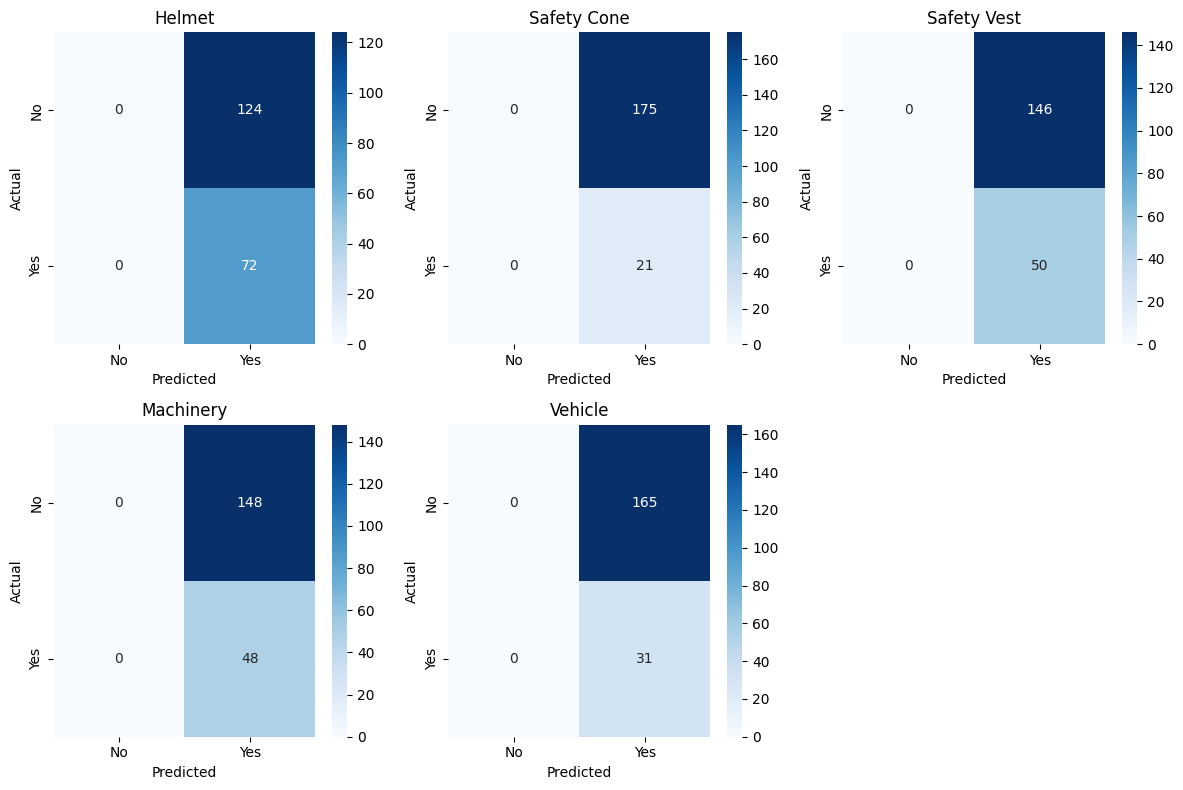

In [ ]:
# Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, label_id in enumerate(mlb.classes_):
    cm = confusion_matrix(y_true[:, i], y_pred[:, i], labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    axes[i].set_title(label_names[label_id])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    fig_ind, ax_ind = plt.subplots()
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_ind,
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    ax_ind.set_title(label_names[label_id])
    fig_ind.savefig(os.path.join(export_dir, f"conf_matrix_label_{label_id}.png"))
    plt.close(fig_ind)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(os.path.join(export_dir, "confusion_matrices_grid.png"))
plt.show()